# Problem Statement

Build and train a Multi-Layer Perceptron (MLP) neural network classifier to classify iris flowers into one of three species — *Setosa*, *Versicolor*, and *Virginica* — based on four features: sepal length, sepal width, petal length, and petal width. Evaluate the trained model's performance using accuracy, a classification report, and a confusion matrix, and visualize the training loss curve.

In [ ]:
# Import required libraries: Matplotlib for plotting, scikit-learn's Iris dataset loader,
# train-test split utility, StandardScaler for feature scaling, MLPClassifier for building
# the neural network, and metrics for evaluating model performance
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay



In [ ]:
# Load the Iris dataset and separate it into features (X) and target labels (y)
iris = load_iris()
X = iris.data
y = iris.target

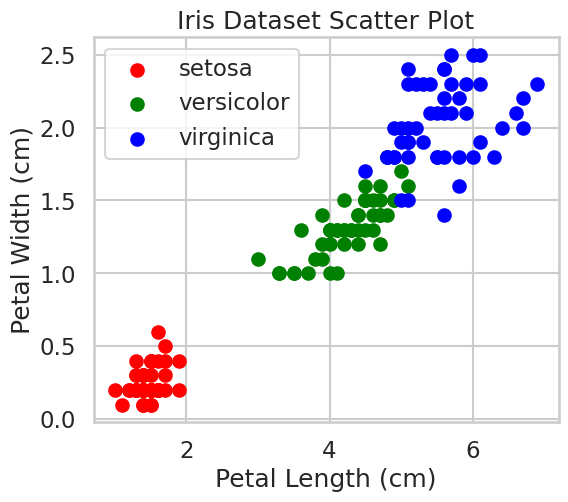

In [ ]:
# Visualize the Iris dataset using a scatter plot of petal length vs. petal width,
# with each of the 3 flower species shown in a different color
plt.figure(figsize=(6,5))
colors = ['red', 'green', 'blue']

for i, color in enumerate(colors):
    plt.scatter(X[y == i, 2], X[y == i, 3],
                color=color,
                label=iris.target_names[i])

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Iris Dataset Scatter Plot")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Split the dataset into training (80%) and testing (20%) sets for model training and evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Standardize the features by removing the mean and scaling to unit variance
# (fit on training data, then apply the same transformation to test data)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
# Define the Multi-Layer Perceptron (MLP) classifier with one hidden layer of 10 neurons,
# ReLU activation, Adam optimizer, and a maximum of 500 training iterations
mlp = MLPClassifier(
    hidden_layer_sizes=(10,),   # One hidden layer with 10 neurons
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)


In [ ]:
# Train the MLP classifier on the scaled training data
mlp.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(10,), max_iter=500, random_state=42)

In [ ]:
# Use the trained model to predict class labels for the test set
y_pred = mlp.predict(X_test)

In [ ]:
# Compute and print the accuracy score along with a detailed classification report
# (precision, recall, F1-score for each class)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))


Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



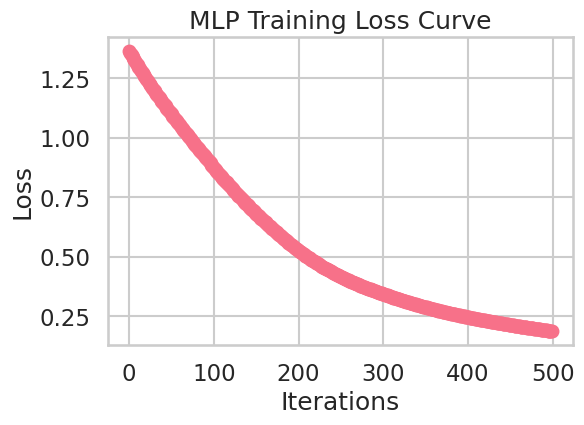

In [ ]:
# Plot the training loss curve to visualize how the model's loss decreased
# over training iterations
plt.figure(figsize=(6,4))
plt.plot(mlp.loss_curve_, marker='o')
plt.title("MLP Training Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

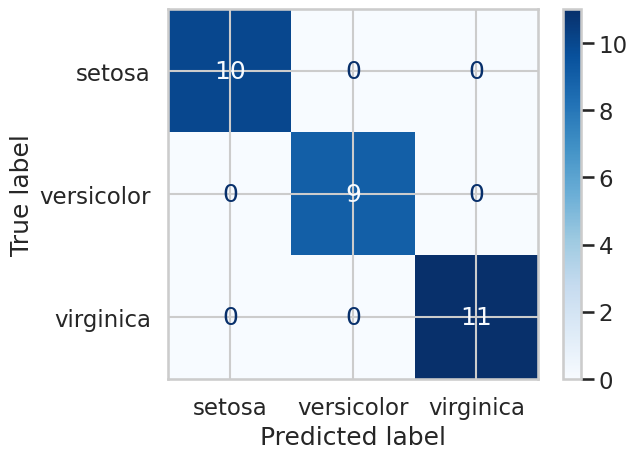

In [ ]:
# Generate and display a confusion matrix comparing actual vs. predicted labels
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=iris.target_names,
    cmap='Blues'
)


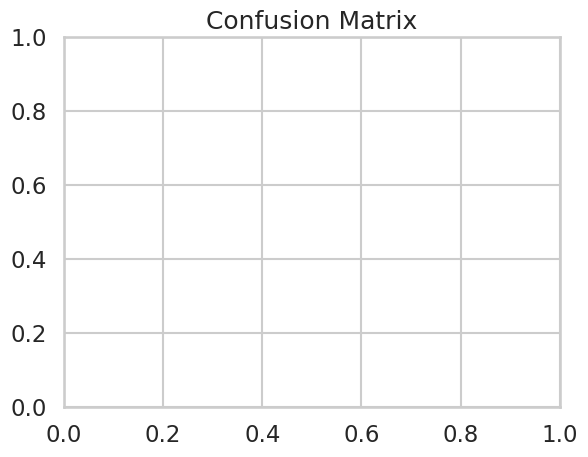

In [ ]:
# Add a title to the confusion matrix plot and display it
plt.title("Confusion Matrix")
plt.show()

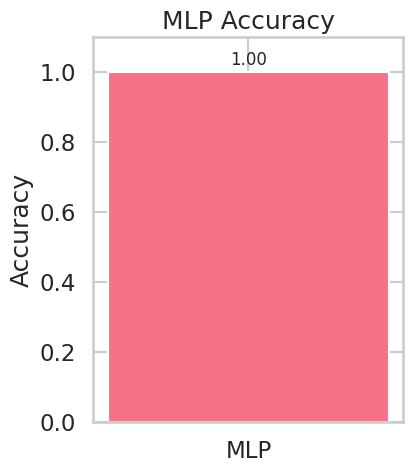

In [ ]:
# Plot a bar chart showing the overall accuracy of the MLP model, with the
# accuracy value labeled on top of the bar
plt.figure(figsize=(4,5))
plt.bar(["MLP"], [accuracy])

plt.ylim(0, 1.1)
plt.ylabel("Accuracy")
plt.title("MLP Accuracy")

plt.text(0, accuracy + 0.02, f"{accuracy:.2f}",
         ha='center', fontsize=12)

plt.show()